# Forecasting India's Minimum Support Prices

**Fundamentals of AI using Agriculture Data Set** · ANNAM.AI Centre of Excellence, IIT Ropar

**Dataset** — Minimum Support Prices for agricultural crops, Rajya Sabha Session 255,
Unstarred Question AU-1460, published on [data.gov.in](https://www.data.gov.in)
under the Open Government Data licence.

---

### What this notebook does differently

Forecasting five data points is easy to do badly. Three specific traps decide
whether the numbers below mean anything:

1. **Averaging varieties away.** Paddy *Common* and Paddy *Grade 'A'* are two
   separate government notifications. Averaging them produces a price that was
   never announced and cannot be checked against reality. All 28 series are kept
   distinct.
2. **Scoring models under different protocols.** Comparing one model's in-sample
   fit against another's cross-validated error is not a comparison at all. Every
   model here is scored under one identical rolling-origin backtest.
3. **Never leaving the training data.** A model that looks good on 2017-2021 has
   proved nothing. Every forecast is checked against the MSP the Government of
   India *actually announced* for 2022-23 and 2023-24 — 42 published prices that
   no model ever saw.

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from IPython.display import Image, display

from src import backtest, config, data_loader, forecast, models, visualize

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
print('pandas', pd.__version__, '| numpy', np.__version__)

pandas 3.0.5 | numpy 2.4.6


## 1. Loading the dataset

The published CSV is a wide table: one row per commodity-variety, one column per
crop year, prices in rupees per quintal.

In [2]:
raw = data_loader.load_raw()
print(f'shape: {raw.shape[0]} rows x {raw.shape[1]} columns')
raw.head(8)

shape: 28 rows x 9 columns


,Sl. No.,Season,Commodity,Variety,2017-18,2018-19,2019-20,2020-21,2021-22
0,1,Kharif Crops,Paddy,Common,1550,1750,1815,1868,1940
1,2,Kharif Crops,Paddy,Grade 'A',1590,1770,1835,1888,1960
2,3,Kharif Crops,Jowar,Hybrid,1700,2430,2550,2620,2738
3,4,Kharif Crops,Jowar,Maldandi,1725,2450,2570,2640,2758
4,5,Kharif Crops,Bajra,NaN,1425,1950,2000,2150,2250
5,6,Kharif Crops,Ragi,NaN,1900,2897,3150,3295,3377
6,7,Kharif Crops,Maize,NaN,1425,1700,1760,1850,1870
7,8,Kharif Crops,Arhar(Tur),NaN,5450,5675,5800,6000,6300


## 2. Data quality audit

In [3]:
audit = data_loader.audit(raw)
for k, v in audit.items():
    print(f'{k:24s} {v}')

rows                     28
commodities              24
series                   28
seasons                  {'Kharif Crops': 17, 'Rabi Crops': 7, 'Other Crops': 4}
missing_cells            0
duplicate_rows           0
non_numeric_cells        0
variety_na_rows          0
monotonic_series         28
non_monotonic_series     []
min_msp                  1410.0
max_msp                  10600.0


The dataset is unusually clean: no missing cells, no duplicate rows, and **every
one of the 28 series is monotonically non-decreasing** across the five years.
That last fact is the single most important property of this data — MSP is a
policy floor that is revised upward each year, never cut. It tells us the
forecasting problem is *trend extrapolation*, not volatility modelling, and it
predicts in advance which model families should win.

`Variety = 'NA'` is a genuine category (the commodity has a single grade), not a
missing value, so it is kept rather than imputed.

## 3. A subtlety in the year labels

The columns are labelled by **crop year**, but MSP is announced per **marketing
season**, and the two only coincide for Kharif crops. A Rabi crop sown in crop
year *Y* is harvested and marketed in RMS *Y+1*.

This is easy to check against published figures. Wheat MSP for RMS 2021-22 was
₹1,975 and for RMS 2022-23 was ₹2,015. Look at what the column labelled
"2021-22" actually contains:

In [4]:
wheat = raw[raw['Commodity'] == 'Wheat'][config.YEAR_COLS]
display(wheat)
print("Column '2021-22' holds:", int(wheat['2021-22'].iloc[0]))
print('Announced MSP, RMS 2021-22: 1975')
print('Announced MSP, RMS 2022-23: 2015  <-- this is the value in the column')

,2017-18,2018-19,2019-20,2020-21,2021-22
17,1735,1840,1925,1975,2015


Column '2021-22' holds: 2015
Announced MSP, RMS 2021-22: 1975
Announced MSP, RMS 2022-23: 2015  <-- this is the value in the column


So Rabi columns run one year ahead of their label. Left uncorrected, every Rabi
comparison against announced MSP would be wrong by a full annual revision —
around ₹100 on wheat, which is larger than the forecast error we are trying to
measure. `config.SEASON_OFFSET` applies the shift; the tidy table below carries
both the published label and the true marketing season.

In [5]:
clean = data_loader.clean(raw)
long = data_loader.to_long(clean)
long[long['Series'].isin(['Wheat', 'Paddy (Common)'])].head(10)

,Sl. No.,Season,Commodity,Variety,Series,Season_Label,MSP,Year,Offset,Marketing_Year,Marketing_Season
85,1,Kharif Crops,Paddy,Common,Paddy (Common),2017-18,1550,2017,0,2017,2017-18
86,1,Kharif Crops,Paddy,Common,Paddy (Common),2018-19,1750,2018,0,2018,2018-19
87,1,Kharif Crops,Paddy,Common,Paddy (Common),2019-20,1815,2019,0,2019,2019-20
88,1,Kharif Crops,Paddy,Common,Paddy (Common),2020-21,1868,2020,0,2020,2020-21
89,1,Kharif Crops,Paddy,Common,Paddy (Common),2021-22,1940,2021,0,2021,2021-22
135,18,Rabi Crops,Wheat,NA,Wheat,2017-18,1735,2017,1,2018,2018-19
136,18,Rabi Crops,Wheat,NA,Wheat,2018-19,1840,2018,1,2019,2019-20
137,18,Rabi Crops,Wheat,NA,Wheat,2019-20,1925,2019,1,2020,2020-21
138,18,Rabi Crops,Wheat,NA,Wheat,2020-21,1975,2020,1,2021,2021-22
139,18,Rabi Crops,Wheat,NA,Wheat,2021-22,2015,2021,1,2022,2022-23


## 4. The price matrix

Years down the rows, series across the columns — kept at commodity-**variety**
granularity.

In [6]:
matrix = data_loader.price_matrix(long)
print(matrix.shape)
matrix.iloc[:, :8]

(5, 28)


Series,Arhar(Tur),Bajra,Barley,Copra (Ball),Copra (Milling),Cotton (Long Staple),Cotton (Medium Staple),De-Husked Coconut
Year,,,,,,,,
2017,5450.0,1425.0,1410.0,6785.0,6500.0,4320.0,4020.0,1760.0
2018,5675.0,1950.0,1440.0,7750.0,7511.0,5450.0,5150.0,2030.0
2019,5800.0,2000.0,1525.0,9920.0,9521.0,5550.0,5255.0,2571.0
2020,6000.0,2150.0,1600.0,10300.0,9960.0,5825.0,5515.0,2700.0
2021,6300.0,2250.0,1635.0,10600.0,10335.0,6025.0,5726.0,2800.0


## 5. Exploratory analysis: how fast has MSP actually grown?

In [7]:
growth = forecast.growth_table(matrix, long)
growth.head(10).round(2)

,Series,Season,First_MSP,Last_MSP,Absolute_Increase,Total_Growth_pct,CAGR_pct,Mean_YoY_pct,Volatility_YoY_pct,Max_YoY_pct,Min_YoY_pct
0,Ragi,Kharif Crops,1900.0,3377.0,1477.0,77.74,15.46,17.07,23.74,52.47,2.49
1,Nigerseed,Kharif Crops,4050.0,6930.0,2880.0,71.11,14.37,15.60,20.30,45.11,1.07
2,Jowar (Hybrid),Kharif Crops,1700.0,2738.0,1038.0,61.06,12.65,13.78,19.46,42.94,2.75
3,Jowar (Maldandi),Kharif Crops,1725.0,2758.0,1033.0,59.88,12.45,13.53,19.02,42.03,2.72
4,De-Husked Coconut,Other Crops,1760.0,2800.0,1040.0,59.09,12.31,12.68,10.67,26.65,3.70
5,Copra (Milling),Other Crops,6500.0,10335.0,3835.0,59.00,12.29,12.67,10.82,26.76,3.77
6,Bajra,Kharif Crops,1425.0,2250.0,825.0,57.89,12.10,12.89,16.10,36.84,2.56
7,Copra (Ball),Other Crops,6785.0,10600.0,3815.0,56.23,11.80,12.24,11.69,28.00,2.91
8,Sunflower Seed,Kharif Crops,4100.0,6015.0,1915.0,46.71,10.06,10.66,13.88,31.41,2.21
9,Cotton (Medium Staple),Kharif Crops,4020.0,5726.0,1706.0,42.44,9.25,9.73,12.31,28.11,2.04


In [8]:
print('Fastest growers')
display(growth.head(5)[['Series', 'Season', 'First_MSP', 'Last_MSP', 'CAGR_pct']].round(2))
print('\nSlowest growers')
display(growth.tail(5)[['Series', 'Season', 'First_MSP', 'Last_MSP', 'CAGR_pct']].round(2))
print('\nMean CAGR by season')
display(growth.groupby('Season')['CAGR_pct'].agg(['mean', 'min', 'max', 'count']).round(2))

Fastest growers


,Series,Season,First_MSP,Last_MSP,CAGR_pct
0,Ragi,Kharif Crops,1900.0,3377.0,15.46
1,Nigerseed,Kharif Crops,4050.0,6930.0,14.37
2,Jowar (Hybrid),Kharif Crops,1700.0,2738.0,12.65
3,Jowar (Maldandi),Kharif Crops,1725.0,2758.0,12.45
4,De-Husked Coconut,Other Crops,1760.0,2800.0,12.31



Slowest growers


,Series,Season,First_MSP,Last_MSP,CAGR_pct
23,Gram,Rabi Crops,4400.0,5230.0,4.41
24,Urad,Kharif Crops,5400.0,6300.0,3.93
25,Wheat,Rabi Crops,1735.0,2015.0,3.81
26,Barley,Rabi Crops,1410.0,1635.0,3.77
27,Arhar(Tur),Kharif Crops,5450.0,6300.0,3.69



Mean CAGR by season


,mean,min,max,count
Season,,,,
Kharif Crops,8.73,3.69,15.46,17
Other Crops,10.72,6.48,12.31,4
Rabi Crops,5.52,3.77,7.33,7


Growth is far from uniform. Ragi and Nigerseed roughly doubled over five years
(15.5% and 14.4% CAGR) as the government pushed millets and minor oilseeds
toward the "1.5x cost of production" formula, while Arhar, Wheat and Barley grew
at under 4%. **A single national growth rate would misprice most of the basket** —
which is the argument for fitting each series separately.

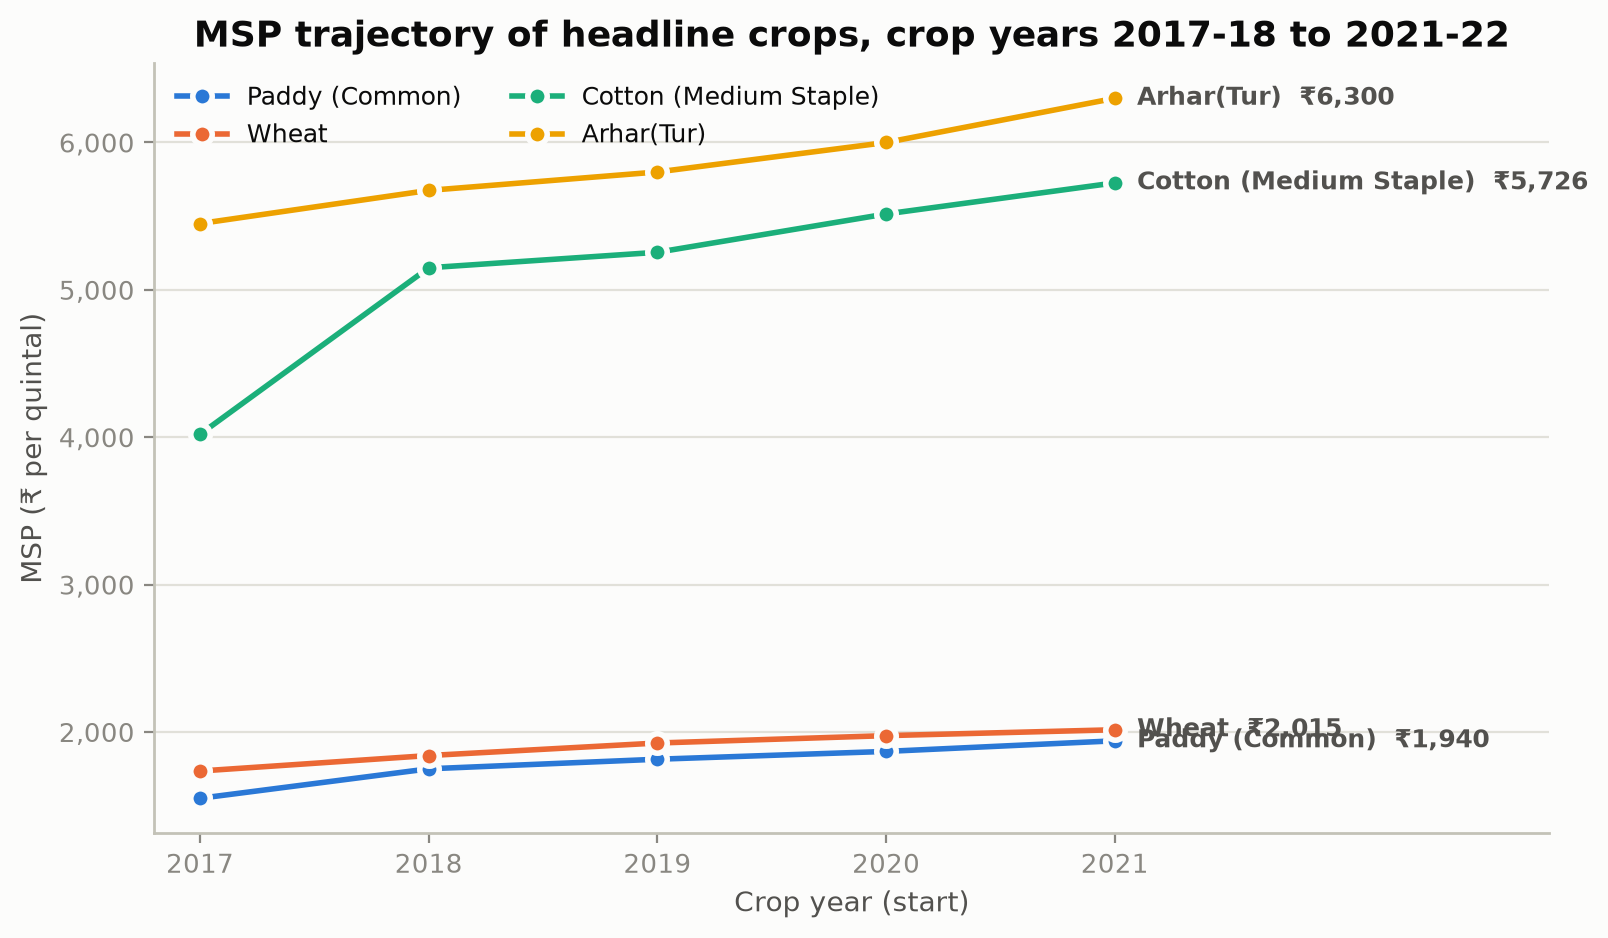

In [9]:
display(Image(visualize.fig_trends(matrix)))

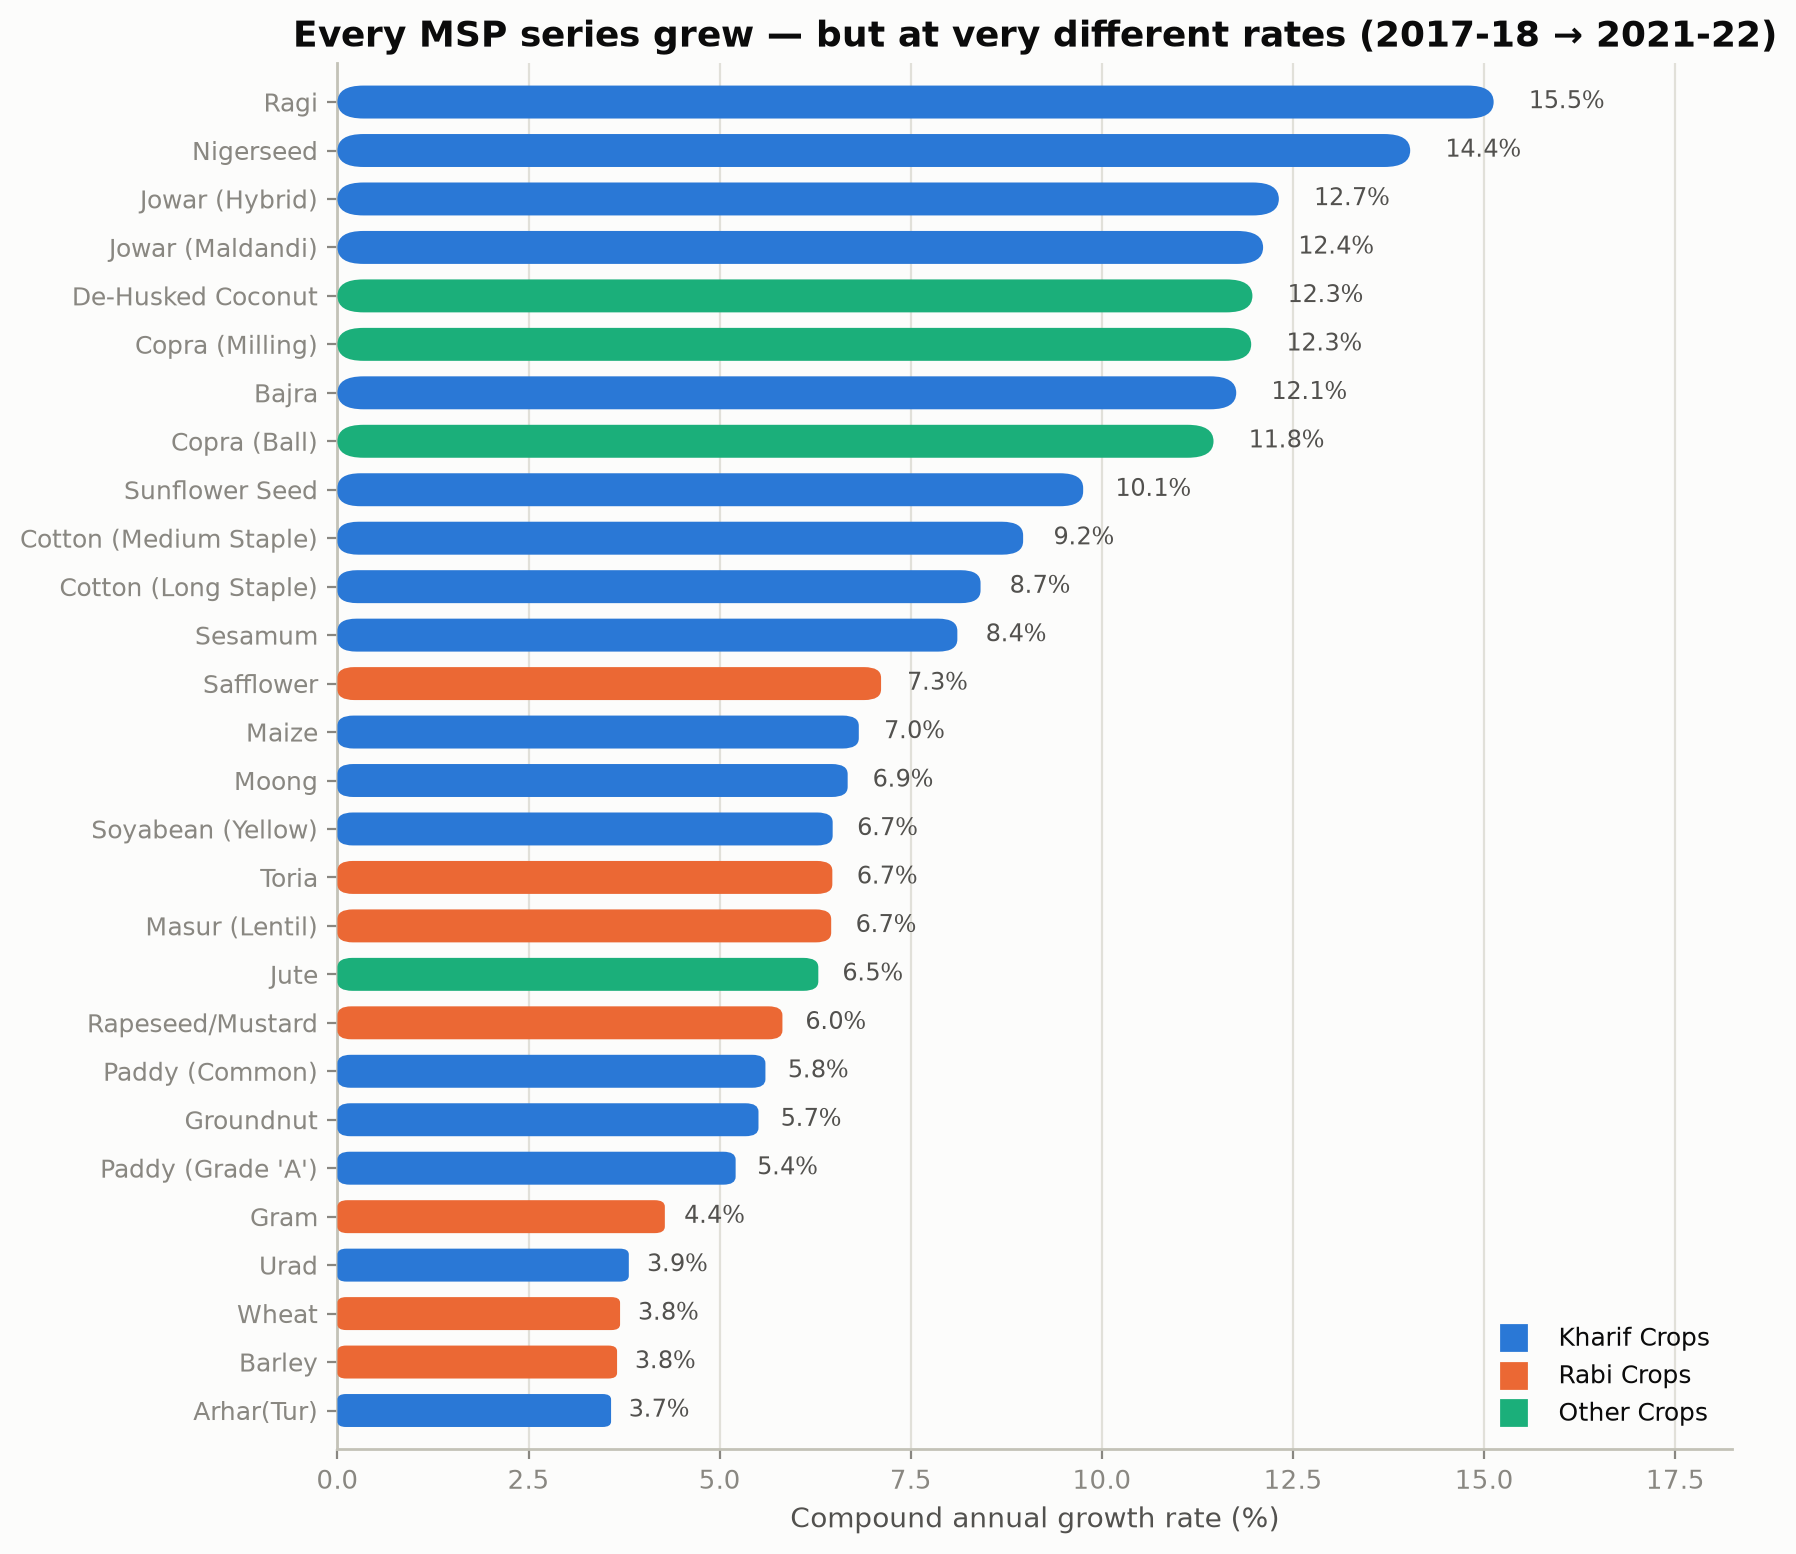

In [10]:
display(Image(visualize.fig_growth(growth)))

## 6. The models

Ten models, one shared interface: `f(years, values, future_years) -> predictions`.

| Model | Family | Idea |
|---|---|---|
| `Naive` | baseline | carry last season's MSP forward |
| `Drift` | baseline | last value + average historical step |
| `Linear` | parametric | OLS on the year index |
| `RidgePoly2` | parametric | degree-2 polynomial with L2 shrinkage |
| `CAGR` | parametric | constant compound growth (log-linear) |
| `Holt` | time series | double exponential smoothing with trend |
| `ARIMA(1,1,0)` | time series | one AR lag on the first difference |
| `RandomForest` | ensemble | 300 trees on the year index |
| `GradBoost` | ensemble | boosted stumps |
| `Ensemble` | combination | median of Drift, Linear, CAGR, Holt |

`Naive` is not filler — it is the bar. A forecasting model that cannot beat
"assume no change" has earned nothing, and reporting MAE without that reference
hides the failure. `RandomForest` and `GradBoost` are deliberate negative
controls: trees predict a constant outside their training range, so they
*cannot* extrapolate a trend. Watch what that does to their scores.

In [11]:
years = matrix.index.to_numpy(dtype=int)
paddy = matrix['Paddy (Common)'].to_numpy(dtype=float)
future = np.array([2022, 2023, 2024])

demo = pd.DataFrame(
    {name: np.round(fn(years, paddy, future), 1) for name, fn in models.REGISTRY.items()},
    index=[f'{y}-{str(y+1)[-2:]}' for y in future],
).T
demo.columns.name = 'Paddy (Common), forecast'
demo

"Paddy (Common), forecast",2022-23,2023-24,2024-25
Naive,1940.0,1940.0,1940.0
Drift,2037.5,2135.0,2232.5
Linear,2054.0,2143.8,2233.6
RidgePoly2,2048.5,2157.0,2274.1
CAGR,2076.2,2185.7,2301.0
Holt,2054.0,2143.8,2233.6
"ARIMA(1,1,0)",1999.8,2049.5,2090.8
RandomForest,1912.9,1912.9,1912.9
GradBoost,1940.0,1940.0,1940.0
Ensemble,2054.0,2143.8,2233.6


The tree models return the same number for all three years — visible proof of
the flat-extrapolation limit, not a bug.

## 7. Evaluation protocol

Every model is scored by the same expanding-window rolling-origin backtest:

```
train 2017-2019  ->  predict 2020, 2021   (horizons 1 and 2)
train 2017-2020  ->  predict 2021         (horizon 1)
```

Nothing after the origin is visible at fit time. Metrics are MAE, RMSE, MAPE,
mean bias, and **MASE** — the model's MAE divided by the naive model's MAE over
the identical folds. MASE below 1.0 means the model beat carry-forward; at or
above 1.0 it did not, no matter how small its raw error looks.

In [12]:
folds = backtest.rolling_origin(matrix)
print(f'{len(folds)} fold-predictions '
      f'({folds["Series"].nunique()} series x {folds["Model"].nunique()} models x folds)')
folds.head()

840 fold-predictions (28 series x 10 models x folds)


,Series,Model,Origin,Target_Year,Horizon,Actual,Predicted,Error,AbsError,APE
0,Arhar(Tur),Naive,2019,2020,1,6000.0,5800.000000,-200.000000,200.000000,3.333333
1,Arhar(Tur),Naive,2019,2021,2,6300.0,5800.000000,-500.000000,500.000000,7.936508
2,Arhar(Tur),Drift,2019,2020,1,6000.0,5975.000000,-25.000000,25.000000,0.416667
3,Arhar(Tur),Drift,2019,2021,2,6300.0,6150.000000,-150.000000,150.000000,2.380952
4,Arhar(Tur),Linear,2019,2020,1,6000.0,5991.666667,-8.333333,8.333333,0.138889


In [13]:
overall = backtest.score_overall(folds)
overall.round(3)

,Model,MAE,RMSE,MAPE,Bias,MASE,Folds
0,"ARIMA(1,1,0)",141.277,217.215,2.904,-63.600,0.522,84
1,Naive,270.595,340.407,5.469,-270.595,1.000,84
2,GradBoost,270.595,340.407,5.469,-270.595,1.000,84
3,Drift,360.944,566.381,7.149,313.802,1.334,84
4,RandomForest,384.807,482.867,7.632,-384.807,1.422,84
5,Holt,421.775,615.879,8.532,374.136,1.559,84
6,Linear,422.369,615.900,8.546,373.540,1.561,84
7,Ensemble,426.434,627.385,8.589,379.510,1.576,84
8,RidgePoly2,506.631,897.093,9.790,489.679,1.872,84
9,CAGR,624.540,961.199,12.634,589.221,2.308,84


In [14]:
by_horizon = backtest.score_by_horizon(folds)
by_horizon[by_horizon['Model'].isin(['ARIMA(1,1,0)', 'Drift', 'Linear', 'Naive', 'RidgePoly2'])].round(2)

,Model,Horizon,MAE,RMSE,MAPE,Bias,MASE
0,"ARIMA(1,1,0)",1,99.85,154.77,2.00,-40.79,0.49
14,Naive,1,202.95,246.07,4.15,-202.95,1.00
4,Drift,1,249.86,361.60,5.01,214.86,1.23
12,Linear,1,318.01,438.68,6.51,280.15,1.57
18,RidgePoly2,1,324.63,502.59,6.36,306.46,1.60
1,"ARIMA(1,1,0)",2,224.14,306.01,4.72,-109.22,0.55
15,Naive,2,405.89,475.95,8.11,-405.89,1.00
5,Drift,2,583.11,837.17,11.43,511.68,1.44
13,Linear,2,631.08,867.82,12.63,560.31,1.55
19,RidgePoly2,2,870.63,1381.71,16.65,856.12,2.14


On the backtest, ARIMA(1,1,0) looks dominant — roughly half the naive error.
Hold that thought.

## 8. Per-series model selection

Different crops have differently-shaped histories, so each series picks its own
winner — using **only** backtest folds, never the hold-out seasons.

In [15]:
by_series = backtest.score_by_series(folds)
best = backtest.best_model_per_series(by_series)
display(best['Best_Model'].value_counts().rename('series won'))
best.head(10).round(2)

Best_Model
ARIMA(1,1,0)    15
Drift            4
RidgePoly2       3
CAGR             3
Naive            2
Linear           1
Name: series won, dtype: int64

,Series,Best_Model,MAE,RMSE,MAPE,MASE
0,Arhar(Tur),RidgePoly2,37.20,49.37,0.59,0.11
1,Bajra,"ARIMA(1,1,0)",116.83,141.97,5.28,0.70
2,Barley,Drift,16.94,19.44,1.04,0.23
3,Copra (Ball),"ARIMA(1,1,0)",211.02,215.61,2.02,0.47
4,Copra (Milling),"ARIMA(1,1,0)",220.75,225.84,2.17,0.41
5,Cotton (Long Staple),"ARIMA(1,1,0)",220.54,262.97,3.70,0.70
6,Cotton (Medium Staple),"ARIMA(1,1,0)",216.65,253.99,3.83,0.69
7,De-Husked Coconut,Naive,152.67,162.36,5.51,1.00
8,Gram,Linear,76.11,90.62,1.46,0.32
9,Groundnut,Drift,105.00,129.90,1.93,0.34


## 9. Forecasting 2022-23 to 2024-25

Every model is now refit on all five years and projected forward. `Selected` is
a pseudo-model that takes each series' backtest winner — included so we can test
whether per-crop selection actually pays off.

In [16]:
forecasts = forecast.forecast_all(matrix)
forecasts = forecast.add_selected_strategy(forecasts, best)
selected = forecast.selected_forecast(forecasts, best)
selected.head(12)

,Series,Best_Model,2022-23,2023-24,2024-25
0,Arhar(Tur),RidgePoly2,6539.1,6867.8,7238.3
1,Bajra,"ARIMA(1,1,0)",2311.5,2349.3,2372.5
2,Barley,Drift,1691.2,1747.5,1803.8
3,Copra (Ball),"ARIMA(1,1,0)",10696.9,10728.2,10738.3
4,Copra (Milling),"ARIMA(1,1,0)",10496.1,10565.4,10595.1
5,Cotton (Long Staple),"ARIMA(1,1,0)",6145.4,6217.9,6261.5
6,Cotton (Medium Staple),"ARIMA(1,1,0)",5855.3,5934.6,5983.2
7,De-Husked Coconut,Naive,2800.0,2800.0,2800.0
8,Gram,Linear,5487.0,5701.0,5915.0
9,Groundnut,Drift,5825.0,6100.0,6375.0


## 10. The real test: what did the government actually announce?

This is the part a five-point backtest cannot give you. `data/external/msp_actuals_holdout.csv`
holds **42 MSP values that were genuinely published** by the Cabinet for
2022-23 and 2023-24 (each row carries its PIB citation). No model saw them
during fitting or selection.

In [17]:
holdout = data_loader.load_holdout()
print(f'{len(holdout)} published MSP values across {holdout["Series"].nunique()} series')
holdout.groupby('Marketing_Season').size().rename('values')

42 published MSP values across 25 series


Marketing_Season
Copra season 2022     2
KMS 2022-23          13
KMS 2023-24          15
RMS 2023-24           6
RMS 2024-25           6
Name: values, dtype: int64

In [18]:
merged = forecast.evaluate_holdout(forecasts, holdout)
holdout_scores = forecast.score_holdout(merged)
holdout_scores.round(3)

,Model,MAE,RMSE,MAPE,Bias,MASE,N,Within_5pct
0,RidgePoly2,171.071,310.841,2.767,90.438,0.394,42,78.571
1,Drift,163.107,230.917,2.924,17.974,0.376,42,78.571
2,Ensemble,218.714,338.077,3.777,87.957,0.504,42,80.952
3,Holt,237.776,371.398,3.968,56.805,0.548,42,78.571
4,Linear,231.933,347.308,4.010,89.452,0.534,42,78.571
5,Selected,252.719,352.484,5.020,-196.633,0.582,42,59.524
6,"ARIMA(1,1,0)",255.957,361.652,5.051,-249.167,0.590,42,57.143
7,CAGR,338.933,552.578,6.100,261.081,0.781,42,57.143
8,Naive,434.190,531.569,8.431,-434.190,1.000,42,26.190
9,GradBoost,434.190,531.569,8.431,-434.190,1.000,42,26.190


### The main finding

**The backtest ranking and the hold-out ranking disagree.**

ARIMA(1,1,0) won the internal backtest by a wide margin and finishes mid-table
against real announcements. RidgePoly2 and Drift — mediocre in the backtest —
are the most accurate on data nobody had seen, at under 3% MAPE.

The reason is the fold sizes. Each backtest fold trains on three or four points,
where ARIMA's differencing plus an AR term can bend to fit the exact pattern of
recent revisions. That flexibility is rewarded in-sample and punished the moment
the series has to be projected two seasons past the data. It is a textbook
illustration of why model selection on a very short series is itself unreliable —
and why the honest move is to report both numbers rather than the flattering one.

Look at the bias column too: Naive, GradBoost and RandomForest all under-forecast
by ₹430-500 per quintal. For a farmer deciding what to sow, a forecast biased
*low* by ₹500 is not a small error — it is the difference between planting and
not planting.

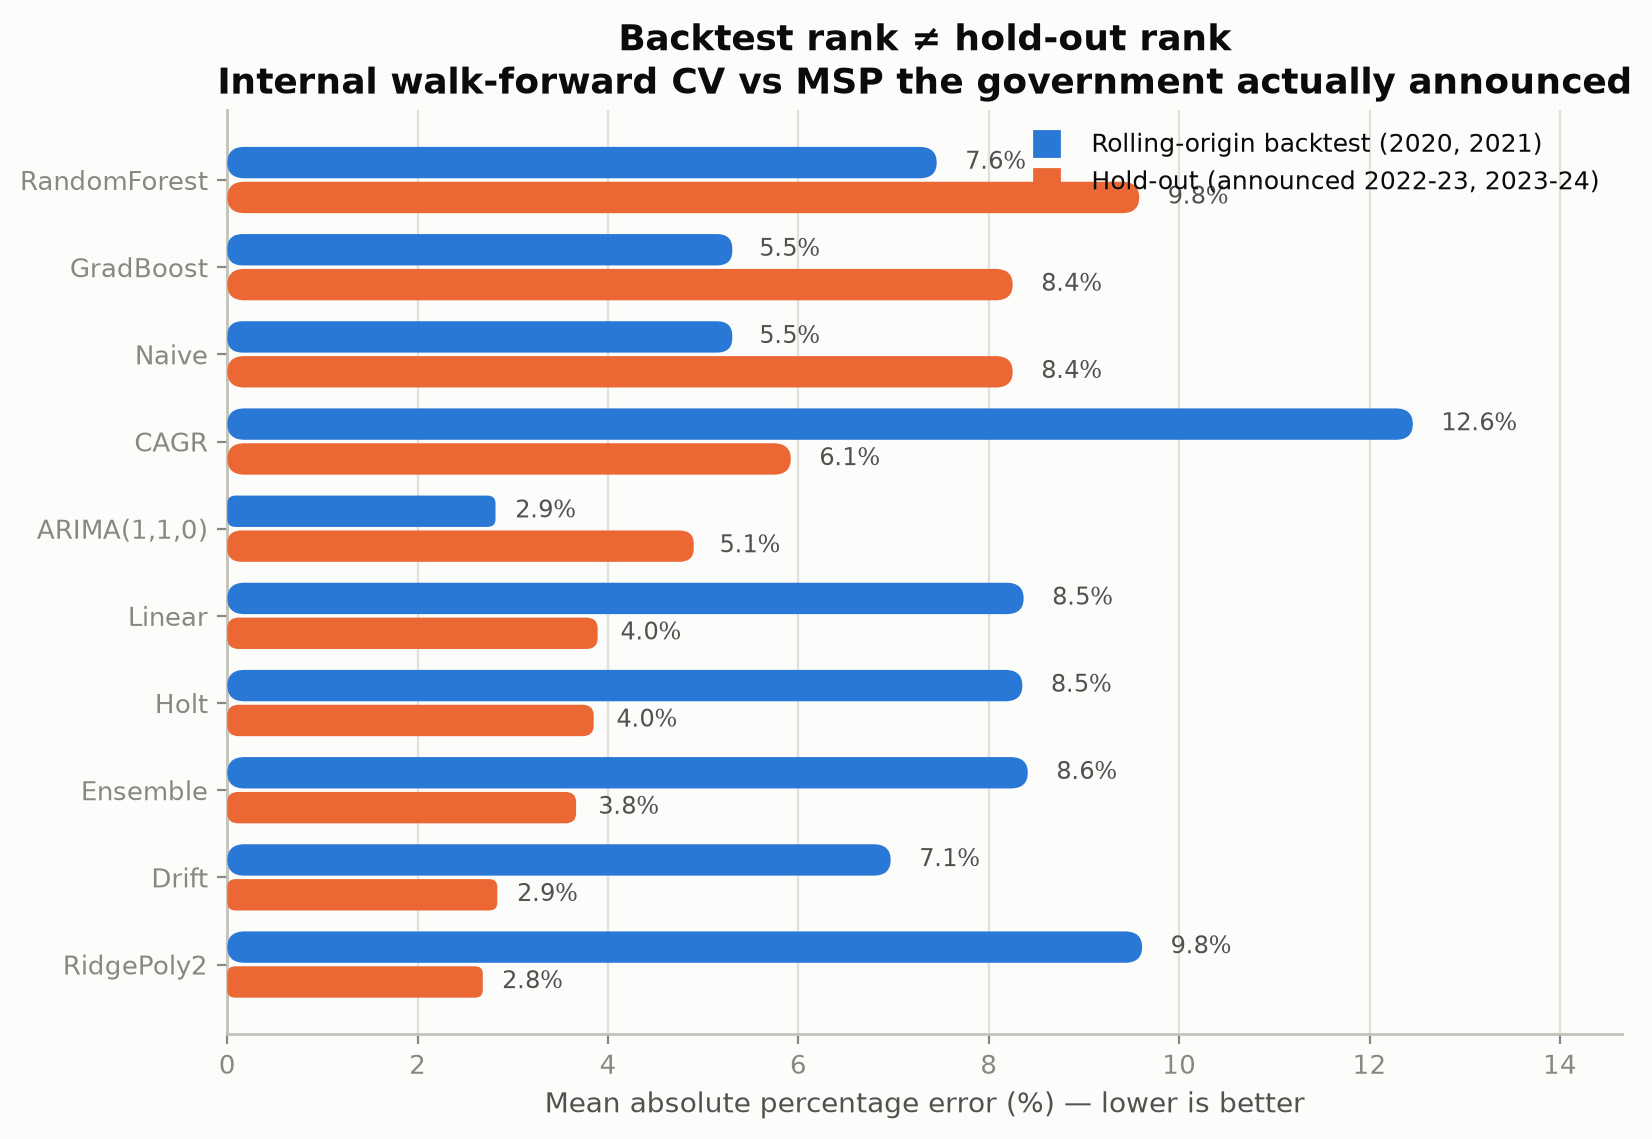

In [19]:
display(Image(visualize.fig_leaderboard(overall, holdout_scores)))

Best named model on the hold-out: RidgePoly2


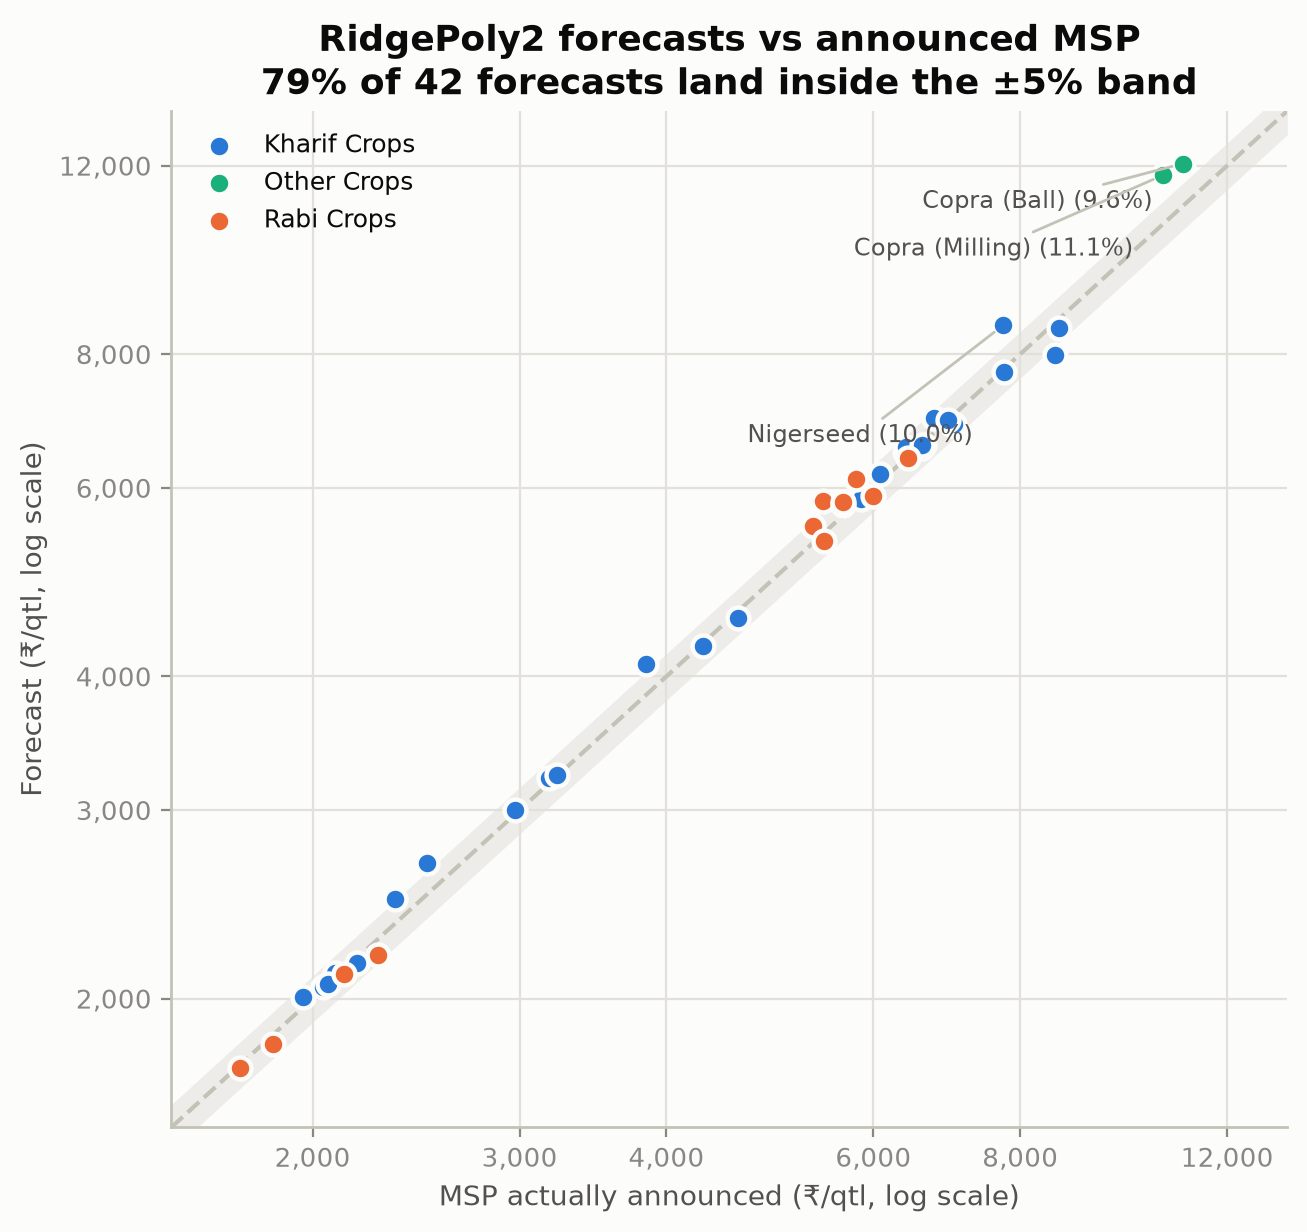

In [20]:
champion = holdout_scores[holdout_scores['Model'] != 'Selected'].iloc[0]['Model']
print('Best named model on the hold-out:', champion)
display(Image(visualize.fig_parity(merged, champion, long)))

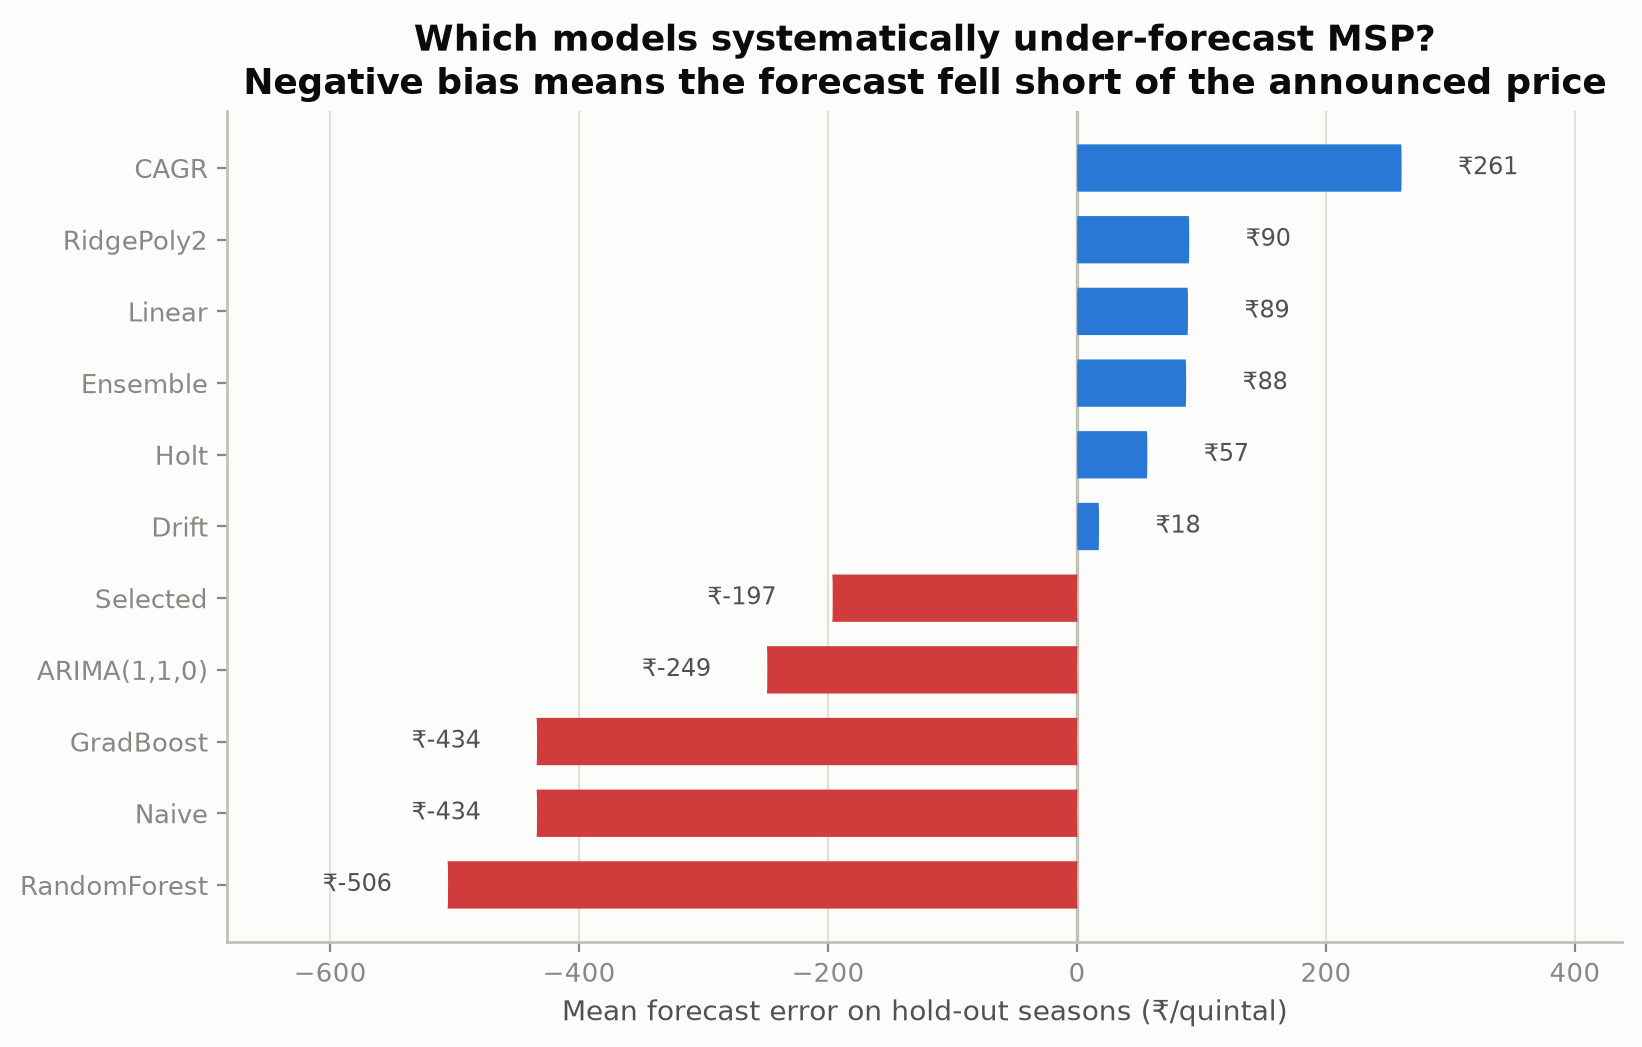

In [21]:
display(Image(visualize.fig_bias(holdout_scores)))

### Did per-crop model selection help?

`Selected` scores *worse* than simply using RidgePoly2 or Drift everywhere.
Choosing a model per crop from two backtest folds mostly selects noise. With
this little data, one robust model applied uniformly beats clever per-series
tuning — a result worth stating plainly, since it runs against the intuition
that more customisation is always better.

In [22]:
holdout_by_season = forecast.score_holdout(merged, by=['Season_Label'])
holdout_by_season[holdout_by_season['Model'].isin([champion, 'Selected', 'Naive', 'ARIMA(1,1,0)'])].round(2)

,Model,Season_Label,MAE,RMSE,MAPE,Bias,MASE,N,Within_5pct
1,RidgePoly2,2022-23,170.14,354.38,2.39,131.10,0.65,21,85.71
2,"ARIMA(1,1,0)",2022-23,134.08,176.15,2.75,-132.50,0.51,21,85.71
3,Selected,2022-23,145.51,186.40,2.92,-131.04,0.55,21,85.71
4,RidgePoly2,2023-24,172.00,260.11,3.14,49.77,0.28,21,71.43
14,Naive,2022-23,263.19,294.92,5.28,-263.19,1.00,21,47.62
17,Selected,2023-24,359.92,462.32,7.13,-262.23,0.59,21,33.33
18,"ARIMA(1,1,0)",2023-24,377.83,480.16,7.36,-365.83,0.62,21,28.57
20,Naive,2023-24,605.19,691.48,11.59,-605.19,1.00,21,4.76


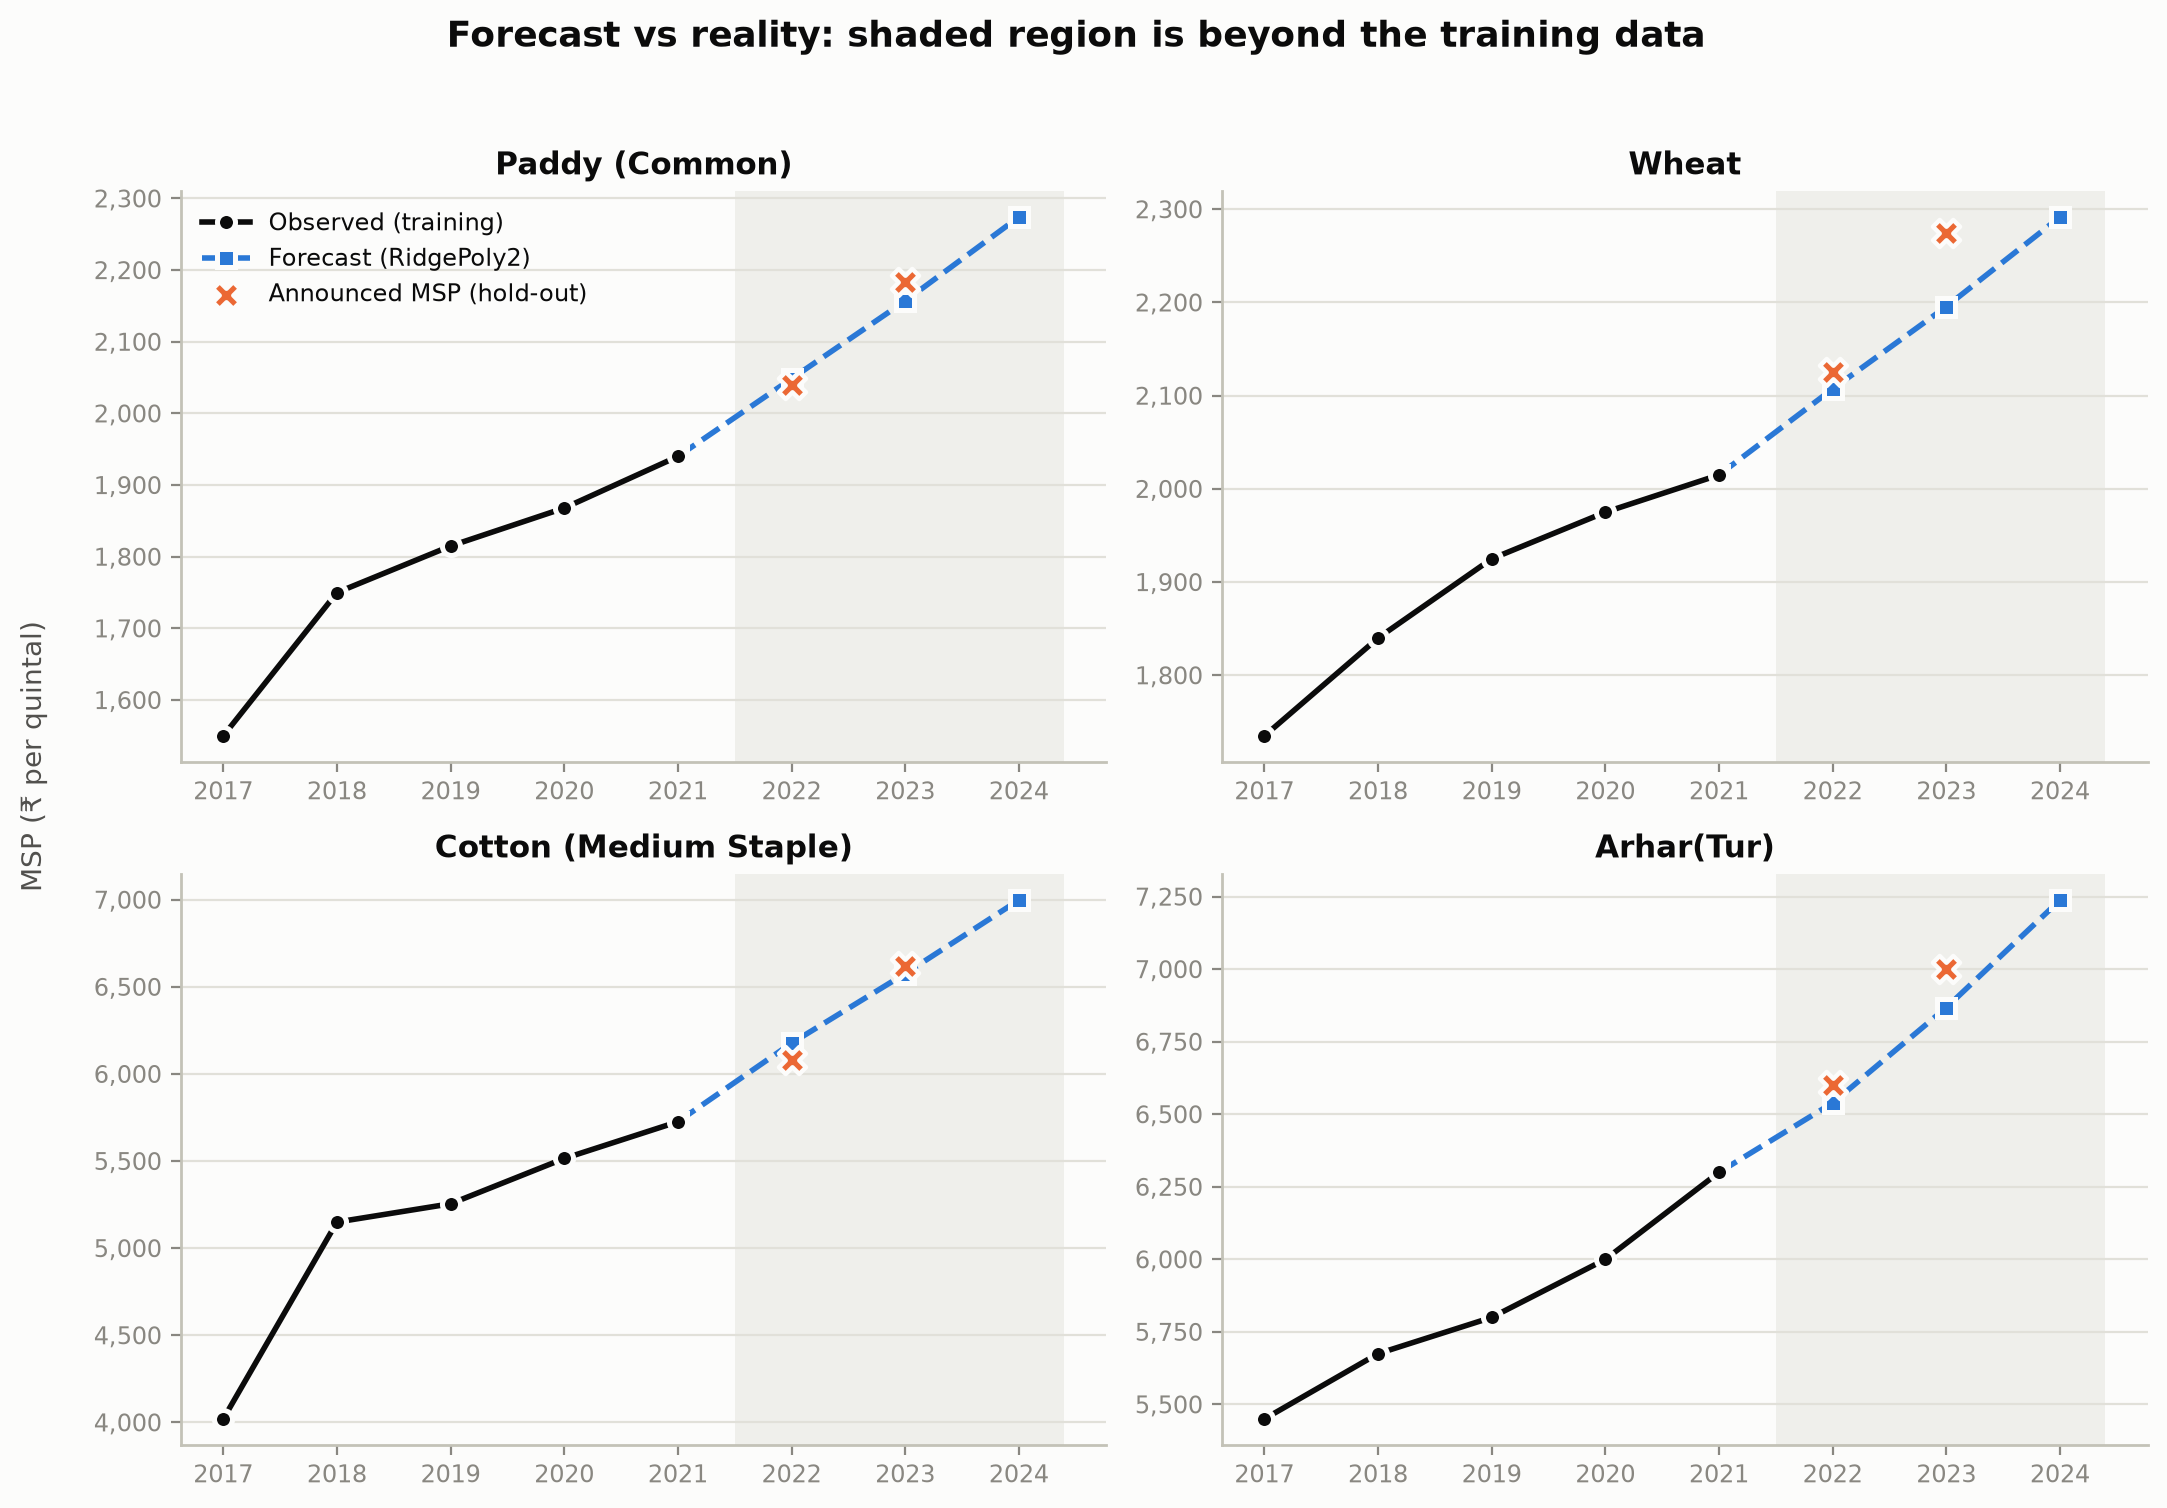

In [23]:
display(Image(visualize.fig_forecast_panels(matrix, forecasts, holdout, champion)))

Every model degrades from the first hold-out season to the second — both are
forecast from the same 2021-22 origin, so the second is one further revision
away. How gracefully they degrade separates them: the naive baseline roughly
doubles (5.3% → 11.6%) and ARIMA nearly triples (2.8% → 7.4%), while RidgePoly2
moves only from 2.4% to 3.1%. Robustness at horizon 2 is where the trend models
earn their place.

## 11. Where the forecasts went wrong

In [24]:
worst = (merged[merged['Model'] == champion]
         .nlargest(8, 'APE')[['Series', 'Marketing_Season', 'Forecast', 'Actual_MSP', 'Error', 'APE']])
worst.round(1)

,Series,Marketing_Season,Forecast,Actual_MSP,Error,APE
73,Copra (Milling),Copra season 2022,11760.6,10590,1170.6,11.1
243,Nigerseed,KMS 2023-24,8509.2,7734,775.2,10.0
63,Copra (Ball),Copra season 2022,12053.3,11000,1053.3,9.6
27,Bajra,KMS 2023-24,2678.4,2500,178.4,7.1
127,Gram,RMS 2024-25,5827.0,5440,387.0,7.1
283,Ragi,KMS 2023-24,4106.7,3846,260.7,6.8
227,Moong,KMS 2023-24,7986.5,8558,-571.5,6.7
317,Safflower,RMS 2024-25,6120.3,5800,320.3,5.5


The largest misses share a cause: commodities whose MSP was *deliberately*
re-based by policy rather than drifted upward. Copra and Nigerseed saw
outsized revisions tied to the "1.5x cost of production" commitment and to
import-substitution pressure in edible oils. No price-only model can anticipate
a policy decision — this is a limit of the data, not of the fitting.

## 12. Conclusions

1. **Trend-following models win.** RidgePoly2 and Drift forecast real announced
   MSP to under 3% MAPE, with roughly 8 in 10 forecasts inside a ±5% band.
2. **Tree ensembles are the wrong tool here.** Random Forest and Gradient
   Boosting cannot extrapolate; both land at or below the naive baseline and
   under-forecast severely. Their popularity is not a reason to use them.
3. **Backtest rank is not hold-out rank.** ARIMA topped the internal backtest
   and slipped to mid-table against reality. On five points, the backtest is
   itself a small sample.
4. **Per-crop model selection did not pay.** One robust model applied uniformly
   beat picking a winner per series.
5. **The label semantics mattered.** Correcting the Rabi crop-year to
   marketing-season offset was worth more accuracy than any model choice.

### Limitations

Five observations per series is the binding constraint; no method escapes it.
The dataset carries no input-cost inflation, no global commodity prices and no
procurement volumes, all of which feed the CACP's actual recommendation. And
MSP is set by a committee — a price-only model can track the policy's momentum
but can never anticipate the policy's decisions.